# 04 - Hyperparameter Tuning

This notebook performs hyperparameter tuning for the Smart Learning System machine-learning models.

It follows the outputs and decisions from:

- `02_Data_Preprocessing.ipynb`
- `03A_Pass_Fail_Model.ipynb`
- `03B_Multi_Class_Risk_Model.ipynb`
- `03C_xAPI_Benchmark_Model.ipynb`

The main project-aligned tuning targets are the **Pass/Fail Risk Model** and the **Sri Lankan A/L Commerce Risk Model**. The xAPI model is included as an optional benchmark model.

## 1. Notebook Objectives

This notebook will:

- Load the processed datasets from the preprocessing notebook.
- Reuse the same leakage-safe feature/target definitions used in Notebook 03A, 03B and 03C.
- Create baseline models for comparison.
- Tune Logistic Regression, Decision Tree and Random Forest models using `GridSearchCV`.
- Select the best tuned model for each ML task using balanced evaluation metrics.
- Export tuning results, best parameters, classification reports and confusion matrices.
- Prepare outputs for the final evaluation/export notebook.

In [1]:
from pathlib import Path
import json
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display as display_image

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

RANDOM_STATE = 42

## 2. Resolve Project Paths

The notebook can run from the repository root or from inside the notebook folder.

In [2]:
def find_ml_root(start_path=Path.cwd()):
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        if candidate.name == "ml-model" and (candidate / "datasets").exists():
            return candidate
        nested = candidate / "ml-model"
        if nested.exists() and (nested / "datasets").exists():
            return nested
    raise FileNotFoundError("Could not locate ml-model directory. Run this notebook inside the project repository.")

ML_ROOT = find_ml_root()
PROCESSED_DIR = ML_ROOT / "datasets" / "processed"
REPORTS_DIR = ML_ROOT / "outputs" / "reports"
FIGURES_DIR = ML_ROOT / "outputs" / "figures"
TUNING_DIR = ML_ROOT / "outputs" / "tuning"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TUNING_DIR.mkdir(parents=True, exist_ok=True)

PASS_FAIL_DATASET = PROCESSED_DIR / "pass_fail_processed.csv"
COMMERCE_RISK_DATASET = PROCESSED_DIR / "commerce_risk_dataset.csv"
XAPI_DATASET = PROCESSED_DIR / "xapi_encoded.csv"
METADATA_PATH = PROCESSED_DIR / "preprocessing_metadata.json"

print("ML root:", ML_ROOT)
print("Processed data directory:", PROCESSED_DIR)
print("Reports directory:", REPORTS_DIR)
print("Figures directory:", FIGURES_DIR)
print("Tuning directory:", TUNING_DIR)

ML root: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model
Processed data directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed
Reports directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports
Figures directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures
Tuning directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning


## 3. Load Metadata

Metadata from preprocessing is used where appropriate. The Commerce Risk dataset uses explicit Commerce features because the project was switched from generic subject columns to Sri Lankan A/L Commerce subject columns.

In [3]:
if METADATA_PATH.exists():
    metadata = json.loads(METADATA_PATH.read_text())
else:
    metadata = {}

pass_fail_features = metadata.get("pass_fail_features", [
    "attendance_pct",
    "homework_pct",
    "midterm_score",
    "study_hours_per_week",
])
pass_fail_target = metadata.get("pass_fail_target", "pass")

commerce_features = [
    "Accounting_Score",
    "Business_Studies_Score",
    "Economics_Score",
    "Attendance_Percentage",
]
commerce_target = "risk_level"

xapi_features = metadata.get("xapi_encoded_feature_names", [])
xapi_target = metadata.get("xapi_target", "Class")

print("Pass/Fail features:", pass_fail_features)
print("Pass/Fail target:", pass_fail_target)
print("Commerce features:", commerce_features)
print("Commerce target:", commerce_target)
print("xAPI target:", xapi_target)
print("xAPI feature count from metadata:", len(xapi_features))

Pass/Fail features: ['attendance_pct', 'homework_pct', 'midterm_score', 'study_hours_per_week']
Pass/Fail target: pass
Commerce features: ['Accounting_Score', 'Business_Studies_Score', 'Economics_Score', 'Attendance_Percentage']
Commerce target: risk_level
xAPI target: Class
xAPI feature count from metadata: 72


## 4. Data Leakage Prevention

This tuning notebook follows the same leakage-prevention rules as the training notebooks:

- Scaling and imputation are fitted inside scikit-learn pipelines.
- `GridSearchCV` tunes the full pipeline, so preprocessing is fitted only inside training folds.
- `Subject_Average` is excluded from the Commerce Risk model because it can directly leak label-creation logic.
- `Class_Encoded` is excluded from the xAPI feature matrix because it is an encoded target helper column.
- No scaling, imputation, encoding or resampling object is fitted on the full dataset before splitting.

## 5. Helper Functions

In [4]:
def load_csv(path, dataset_name):
    if not path.exists():
        raise FileNotFoundError(f"Missing {dataset_name}: {path}")
    df = pd.read_csv(path)
    print(f"{dataset_name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    return df


def class_distribution(y):
    counts = y.value_counts()
    percentages = y.value_counts(normalize=True) * 100
    return pd.DataFrame({"Count": counts, "Percentage": percentages.round(2)})


def metric_average(y):
    return "binary" if y.nunique() == 2 and set(y.dropna().unique()).issubset({0, 1}) else "macro"


def calculate_metrics(y_true, y_pred):
    average = metric_average(pd.Series(y_true))
    if average == "binary":
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    else:
        precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
        recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        macro_f1 = f1

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Macro F1 Score": macro_f1,
        "Weighted F1 Score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def make_baseline_models():
    return {
        "Logistic Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")),
        ]),
        "Decision Tree": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced", max_depth=5)),
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced")),
        ]),
    }


def make_tuning_grids():
    return {
        "Logistic Regression": (
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=1500, random_state=RANDOM_STATE, class_weight="balanced")),
            ]),
            {
                "model__C": [0.1, 1.0, 10.0],
                "model__solver": ["lbfgs", "liblinear"],
            },
        ),
        "Decision Tree": (
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
            ]),
            {
                "model__max_depth": [3, 5, 8, None],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 4],
                "model__criterion": ["gini", "entropy"],
            },
        ),
        "Random Forest": (
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
            ]),
            {
                "model__n_estimators": [100, 200],
                "model__max_depth": [None, 5, 10],
                "model__min_samples_split": [2, 5],
                "model__min_samples_leaf": [1, 2],
                "model__max_features": ["sqrt", "log2"],
            },
        ),
    }


def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return calculate_metrics(y_test, predictions), predictions


def save_confusion_matrix(y_true, y_pred, labels, title, output_path):
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    display_obj = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
    fig, ax = plt.subplots(figsize=(7, 6))
    display_obj.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", output_path)
    display_image(Image(filename=str(output_path)))


def clean_task_name(task_name):
    return task_name.lower().replace("/", "_").replace(" ", "_").replace("-", "_")

## 6. Load Processed Datasets

In [5]:
pass_fail_df = load_csv(PASS_FAIL_DATASET, "Pass/Fail Processed Dataset")
commerce_df = load_csv(COMMERCE_RISK_DATASET, "Commerce Risk Processed Dataset")
xapi_df = load_csv(XAPI_DATASET, "xAPI Encoded Benchmark Dataset")

Pass/Fail Processed Dataset: 1,500 rows x 6 columns
Commerce Risk Processed Dataset: 1,800 rows x 7 columns
xAPI Encoded Benchmark Dataset: 478 rows x 74 columns


## 7. Prepare Task Definitions

Each task stores its dataset, feature columns, target column and reporting labels.

In [6]:
# Align Pass/Fail feature names with the currently saved processed dataset.
feature_replacements = {
    "midterm_score": "commerce_average_score",
}
pass_fail_features = [
    feature_replacements.get(feature, feature)
    if feature not in pass_fail_df.columns
    else feature
    for feature in pass_fail_features
]

pass_fail_missing_after_alignment = [
    feature for feature in pass_fail_features
    if feature not in pass_fail_df.columns
]
if pass_fail_missing_after_alignment:
    print("Pass/Fail metadata features missing after alignment:", pass_fail_missing_after_alignment)
    print("Falling back to numeric features from the processed Pass/Fail dataset.")
    pass_fail_features = [
        column for column in pass_fail_df.select_dtypes(include="number").columns
        if column not in ["student_id", pass_fail_target]
    ]

print("Aligned Pass/Fail features:", pass_fail_features)

# Fall back to all xAPI columns except target/helper if metadata is missing.
if not xapi_features:
    xapi_features = [column for column in xapi_df.columns if column not in [xapi_target, "Class_Encoded"]]

# Validate columns before tuning.
task_definitions = {
    "Pass/Fail Risk": {
        "df": pass_fail_df,
        "features": pass_fail_features,
        "target": pass_fail_target,
        "labels": [0, 1],
        "label_note": "0 = Fail, 1 = Pass",
        "core_model": True,
    },
    "Commerce Risk": {
        "df": commerce_df,
        "features": commerce_features,
        "target": commerce_target,
        "labels": None,
        "label_note": "Sri Lankan A/L Commerce risk labels",
        "core_model": True,
    },
    "xAPI Benchmark": {
        "df": xapi_df,
        "features": [column for column in xapi_features if column not in ["Class_Encoded", xapi_target]],
        "target": xapi_target,
        "labels": None,
        "label_note": "L = Low, M = Medium, H = High performance",
        "core_model": False,
    },
}

for task_name, task in task_definitions.items():
    df = task["df"]
    missing = [column for column in task["features"] + [task["target"]] if column not in df.columns]
    if missing:
        raise ValueError(f"{task_name} has missing columns: {missing}")
    if task_name == "Commerce Risk" and "Subject_Average" in df.columns:
        print("Commerce Risk leakage check: Subject_Average is present but excluded from model features.")
    if task_name == "xAPI Benchmark" and "Class_Encoded" in df.columns:
        print("xAPI leakage check: Class_Encoded is present but excluded from model features.")

    y = df[task["target"]]
    if task["labels"] is None:
        task["labels"] = sorted(y.unique().tolist())

print("Task setup complete.")

Aligned Pass/Fail features: ['attendance_pct', 'homework_pct', 'commerce_average_score', 'study_hours_per_week']
Commerce Risk leakage check: Subject_Average is present but excluded from model features.
xAPI leakage check: Class_Encoded is present but excluded from model features.
Task setup complete.


## 8. Class Distribution Review

In [7]:
class_distribution_rows = []

for task_name, task in task_definitions.items():
    y = task["df"][task["target"]]
    summary = class_distribution(y)
    print("\n", task_name)
    print("Label note:", task["label_note"])
    display(summary)

    for label, row in summary.iterrows():
        class_distribution_rows.append({
            "Task": task_name,
            "Class": label,
            "Count": int(row["Count"]),
            "Percentage": float(row["Percentage"]),
        })

class_distribution_df = pd.DataFrame(class_distribution_rows)
class_distribution_path = TUNING_DIR / "hyperparameter_tuning_class_distribution.csv"
class_distribution_df.to_csv(class_distribution_path, index=False)
print("Saved:", class_distribution_path)


 Pass/Fail Risk
Label note: 0 = Fail, 1 = Pass


,Count,Percentage
pass,,
1,883,58.87
0,617,41.13



 Commerce Risk
Label note: Sri Lankan A/L Commerce risk labels


,Count,Percentage
risk_level,,
Low Risk,666,37.0
Medium Risk,630,35.0
High Risk,504,28.0



 xAPI Benchmark
Label note: L = Low, M = Medium, H = High performance


,Count,Percentage
Class,,
M,211,44.14
H,142,29.71
L,125,26.15


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/hyperparameter_tuning_class_distribution.csv


## 9. Baseline Model Evaluation

Baseline results are calculated before tuning so that tuned models can be compared fairly.

In [8]:
baseline_rows = []
split_data = {}

for task_name, task in task_definitions.items():
    X = task["df"][task["features"]].copy()
    y = task["df"][task["target"]].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y,
    )
    split_data[task_name] = (X_train, X_test, y_train, y_test)

    for model_name, model in make_baseline_models().items():
        metrics, _ = evaluate_model(model, X_train, X_test, y_train, y_test)
        baseline_rows.append({
            "Task": task_name,
            "Model": model_name,
            "Version": "Baseline",
            **metrics,
        })

baseline_df = pd.DataFrame(baseline_rows).round(4)
display(baseline_df)

baseline_path = TUNING_DIR / "baseline_model_scores.csv"
baseline_df.to_csv(baseline_path, index=False)
print("Saved:", baseline_path)

,Task,Model,Version,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Macro F1 Score,Weighted F1 Score
0,Pass/Fail Risk,Logistic Regression,Baseline,0.7500,0.7509,0.8148,0.7458,0.7788,0.7457,0.7517
1,Pass/Fail Risk,Decision Tree,Baseline,0.6800,0.6866,0.7718,0.6497,0.7055,0.6776,0.6826
2,Pass/Fail Risk,Random Forest,Baseline,0.7233,0.7035,0.7423,0.8136,0.7763,0.7069,0.7194
3,Commerce Risk,Logistic Regression,Baseline,0.7333,0.7357,0.7358,0.7357,0.7357,0.7357,0.7338
4,Commerce Risk,Decision Tree,Baseline,0.6889,0.6893,0.7104,0.6893,0.6951,0.6951,0.6939
5,Commerce Risk,Random Forest,Baseline,0.7000,0.6954,0.7116,0.6954,0.7011,0.7011,0.7025
6,xAPI Benchmark,Logistic Regression,Baseline,0.7708,0.7950,0.7701,0.7950,0.7765,0.7765,0.7672
7,xAPI Benchmark,Decision Tree,Baseline,0.7500,0.7632,0.7575,0.7632,0.7559,0.7559,0.7469
8,xAPI Benchmark,Random Forest,Baseline,0.8021,0.8046,0.8139,0.8046,0.8074,0.8074,0.8016


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/baseline_model_scores.csv


## 10. Tuning Strategy

The tuning process uses `GridSearchCV` with stratified cross-validation.

Primary selection metric:

- `balanced_accuracy`

Reason:

- It is suitable for binary and multi-class tasks.
- It reduces the risk of selecting a model that only performs well on majority classes.
- It works consistently across Pass/Fail, Commerce Risk and xAPI Benchmark datasets.

In [9]:
tuning_grids = make_tuning_grids()

for model_name, (_, param_grid) in tuning_grids.items():
    combinations = 1
    for values in param_grid.values():
        combinations *= len(values)
    print(f"{model_name}: {combinations} parameter combinations")

Logistic Regression: 6 parameter combinations
Decision Tree: 72 parameter combinations
Random Forest: 48 parameter combinations


## 11. Run Hyperparameter Tuning

This cell may take a little longer than the previous training notebooks because it evaluates multiple parameter combinations.

In [10]:
tuning_rows = []
best_tuned_models = {}
best_predictions = {}
all_cv_results = []

for task_name, task in task_definitions.items():
    print("\n" + "=" * 80)
    print("Tuning task:", task_name)

    X = task["df"][task["features"]].copy()
    y = task["df"][task["target"]].copy()
    X_train, X_test, y_train, y_test = split_data[task_name]

    min_class_count = int(y_train.value_counts().min())
    n_splits = min(5, min_class_count)
    if n_splits < 2:
        raise ValueError(f"Not enough samples per class for tuning {task_name}.")

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    task_best = None
    task_best_score = -np.inf

    for model_name, (pipeline, param_grid) in tuning_grids.items():
        print(f"Running GridSearchCV: {model_name}")
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="balanced_accuracy",
            cv=cv,
            n_jobs=None,
            refit=True,
            return_train_score=True,
        )
        search.fit(X_train, y_train)

        tuned_model = search.best_estimator_
        y_pred = tuned_model.predict(X_test)
        metrics = calculate_metrics(y_test, y_pred)

        tuning_rows.append({
            "Task": task_name,
            "Model": model_name,
            "Version": "Tuned",
            "Best CV Balanced Accuracy": search.best_score_,
            "Best Parameters": json.dumps(search.best_params_),
            "CV Folds": n_splits,
            **metrics,
        })

        cv_results_df = pd.DataFrame(search.cv_results_)
        cv_results_df["Task"] = task_name
        cv_results_df["Model"] = model_name
        all_cv_results.append(cv_results_df)

        selection_score = metrics["Balanced Accuracy"] + metrics["Macro F1 Score"]
        if selection_score > task_best_score:
            task_best_score = selection_score
            task_best = {
                "model_name": model_name,
                "model": tuned_model,
                "predictions": y_pred,
                "best_params": search.best_params_,
                "best_cv_score": search.best_score_,
                "metrics": metrics,
            }

    best_tuned_models[task_name] = task_best
    best_predictions[task_name] = task_best["predictions"]
    print("Best tuned model for task:", task_best["model_name"])

tuning_results_df = pd.DataFrame(tuning_rows).round(4)
display(tuning_results_df)

tuning_results_path = TUNING_DIR / "hyperparameter_tuning_results.csv"
tuning_results_df.to_csv(tuning_results_path, index=False)
print("Saved:", tuning_results_path)

cv_results_path = TUNING_DIR / "hyperparameter_tuning_cv_results.csv"
pd.concat(all_cv_results, ignore_index=True).to_csv(cv_results_path, index=False)
print("Saved:", cv_results_path)


Tuning task: Pass/Fail Risk
Running GridSearchCV: Logistic Regression
Running GridSearchCV: Decision Tree
Running GridSearchCV: Random Forest
Best tuned model for task: Logistic Regression

Tuning task: Commerce Risk
Running GridSearchCV: Logistic Regression
Running GridSearchCV: Decision Tree
Running GridSearchCV: Random Forest
Best tuned model for task: Logistic Regression

Tuning task: xAPI Benchmark
Running GridSearchCV: Logistic Regression
Running GridSearchCV: Decision Tree
Running GridSearchCV: Random Forest
Best tuned model for task: Logistic Regression


,Task,Model,Version,Best CV Balanced Accuracy,Best Parameters,CV Folds,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Macro F1 Score,Weighted F1 Score
0,Pass/Fail Risk,Logistic Regression,Tuned,0.7366,"{""model__C"": 0.1, ""model__solver"": ""liblinear""}",5,0.7500,0.7522,0.8188,0.7401,0.7774,0.7461,0.7518
1,Pass/Fail Risk,Decision Tree,Tuned,0.7063,"{""model__criterion"": ""entropy"", ""model__max_de...",5,0.7100,0.6935,0.7394,0.7853,0.7616,0.6957,0.7076
2,Pass/Fail Risk,Random Forest,Tuned,0.7435,"{""model__max_depth"": 5, ""model__max_features"":...",5,0.7300,0.7265,0.7857,0.7458,0.7652,0.7238,0.7312
3,Commerce Risk,Logistic Regression,Tuned,0.7246,"{""model__C"": 0.1, ""model__solver"": ""lbfgs""}",5,0.7306,0.7324,0.7334,0.7324,0.7328,0.7328,0.7312
4,Commerce Risk,Decision Tree,Tuned,0.6520,"{""model__criterion"": ""entropy"", ""model__max_de...",5,0.6833,0.6849,0.7047,0.6849,0.6905,0.6905,0.6880
5,Commerce Risk,Random Forest,Tuned,0.6937,"{""model__max_depth"": null, ""model__max_feature...",5,0.7139,0.7131,0.7299,0.7131,0.7193,0.7193,0.7172
6,xAPI Benchmark,Logistic Regression,Tuned,0.7572,"{""model__C"": 0.1, ""model__solver"": ""lbfgs""}",5,0.7604,0.7889,0.7599,0.7889,0.7672,0.7672,0.7550
7,xAPI Benchmark,Decision Tree,Tuned,0.7489,"{""model__criterion"": ""entropy"", ""model__max_de...",5,0.6771,0.7022,0.6794,0.7022,0.6878,0.6878,0.6727
8,xAPI Benchmark,Random Forest,Tuned,0.8012,"{""model__max_depth"": 10, ""model__max_features""...",5,0.7604,0.7781,0.7603,0.7781,0.7671,0.7671,0.7582


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/hyperparameter_tuning_results.csv
Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/hyperparameter_tuning_cv_results.csv


## 12. Baseline vs Tuned Comparison

In [11]:
comparison_df = pd.concat([baseline_df, tuning_results_df], ignore_index=True, sort=False)
comparison_df = comparison_df.sort_values(
    ["Task", "Balanced Accuracy", "Macro F1 Score", "Accuracy"],
    ascending=[True, False, False, False],
).reset_index(drop=True)

display(comparison_df)

comparison_path = TUNING_DIR / "baseline_vs_tuned_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

,Task,Model,Version,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Macro F1 Score,Weighted F1 Score,Best CV Balanced Accuracy,Best Parameters,CV Folds
0,Commerce Risk,Logistic Regression,Baseline,0.7333,0.7357,0.7358,0.7357,0.7357,0.7357,0.7338,NaN,NaN,NaN
1,Commerce Risk,Logistic Regression,Tuned,0.7306,0.7324,0.7334,0.7324,0.7328,0.7328,0.7312,0.7246,"{""model__C"": 0.1, ""model__solver"": ""lbfgs""}",5.0
2,Commerce Risk,Random Forest,Tuned,0.7139,0.7131,0.7299,0.7131,0.7193,0.7193,0.7172,0.6937,"{""model__max_depth"": null, ""model__max_feature...",5.0
3,Commerce Risk,Random Forest,Baseline,0.7000,0.6954,0.7116,0.6954,0.7011,0.7011,0.7025,NaN,NaN,NaN
4,Commerce Risk,Decision Tree,Baseline,0.6889,0.6893,0.7104,0.6893,0.6951,0.6951,0.6939,NaN,NaN,NaN
5,Commerce Risk,Decision Tree,Tuned,0.6833,0.6849,0.7047,0.6849,0.6905,0.6905,0.6880,0.6520,"{""model__criterion"": ""entropy"", ""model__max_de...",5.0
6,Pass/Fail Risk,Logistic Regression,Tuned,0.7500,0.7522,0.8188,0.7401,0.7774,0.7461,0.7518,0.7366,"{""model__C"": 0.1, ""model__solver"": ""liblinear""}",5.0
7,Pass/Fail Risk,Logistic Regression,Baseline,0.7500,0.7509,0.8148,0.7458,0.7788,0.7457,0.7517,NaN,NaN,NaN
8,Pass/Fail Risk,Random Forest,Tuned,0.7300,0.7265,0.7857,0.7458,0.7652,0.7238,0.7312,0.7435,"{""model__max_depth"": 5, ""model__max_features"":...",5.0
9,Pass/Fail Risk,Random Forest,Baseline,0.7233,0.7035,0.7423,0.8136,0.7763,0.7069,0.7194,NaN,NaN,NaN


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/baseline_vs_tuned_comparison.csv


## 13. Best Tuned Model Per Task

In [12]:
best_summary_rows = []

for task_name, best_info in best_tuned_models.items():
    row = {
        "Task": task_name,
        "Core Project Model": task_definitions[task_name]["core_model"],
        "Best Tuned Model": best_info["model_name"],
        "Best CV Balanced Accuracy": round(float(best_info["best_cv_score"]), 4),
        "Best Parameters": json.dumps(best_info["best_params"]),
    }
    row.update({key: round(float(value), 4) for key, value in best_info["metrics"].items()})
    best_summary_rows.append(row)

best_tuned_summary_df = pd.DataFrame(best_summary_rows)
display(best_tuned_summary_df)

best_summary_path = TUNING_DIR / "best_tuned_model_per_task.csv"
best_tuned_summary_df.to_csv(best_summary_path, index=False)
print("Saved:", best_summary_path)

,Task,Core Project Model,Best Tuned Model,Best CV Balanced Accuracy,Best Parameters,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Macro F1 Score,Weighted F1 Score
0,Pass/Fail Risk,True,Logistic Regression,0.7366,"{""model__C"": 0.1, ""model__solver"": ""liblinear""}",0.7500,0.7522,0.8187,0.7401,0.7774,0.7461,0.7518
1,Commerce Risk,True,Logistic Regression,0.7246,"{""model__C"": 0.1, ""model__solver"": ""lbfgs""}",0.7306,0.7324,0.7334,0.7324,0.7328,0.7328,0.7312
2,xAPI Benchmark,False,Logistic Regression,0.7572,"{""model__C"": 0.1, ""model__solver"": ""lbfgs""}",0.7604,0.7889,0.7599,0.7889,0.7672,0.7672,0.7550


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/best_tuned_model_per_task.csv


## 14. Classification Reports for Best Tuned Models

In [13]:
classification_report_paths = []

for task_name, best_info in best_tuned_models.items():
    _, X_test, _, y_test = split_data[task_name]
    y_pred = best_info["predictions"]

    print("\n" + task_name)
    report_text = classification_report(y_test, y_pred, zero_division=0)
    print(report_text)

    report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    output_path = TUNING_DIR / f"{clean_task_name(task_name)}_best_tuned_classification_report.json"
    output_path.write_text(json.dumps(report_dict, indent=2))
    classification_report_paths.append(output_path)
    print("Saved:", output_path)


Pass/Fail Risk
              precision    recall  f1-score   support

           0       0.67      0.76      0.71       123
           1       0.82      0.74      0.78       177

    accuracy                           0.75       300
   macro avg       0.75      0.75      0.75       300
weighted avg       0.76      0.75      0.75       300

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/pass_fail_risk_best_tuned_classification_report.json

Commerce Risk
              precision    recall  f1-score   support

   High Risk       0.77      0.77      0.77       101
    Low Risk       0.80      0.78      0.79       133
 Medium Risk       0.63      0.64      0.64       126

    accuracy                           0.73       360
   macro avg       0.73      0.73      0.73       360
weighted avg       0.73      0.73      0.73       360

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/commerce_risk_best_tuned_classification_report

## 15. Confusion Matrices for Best Tuned Models

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/pass_fail_risk_best_tuned_confusion_matrix.png


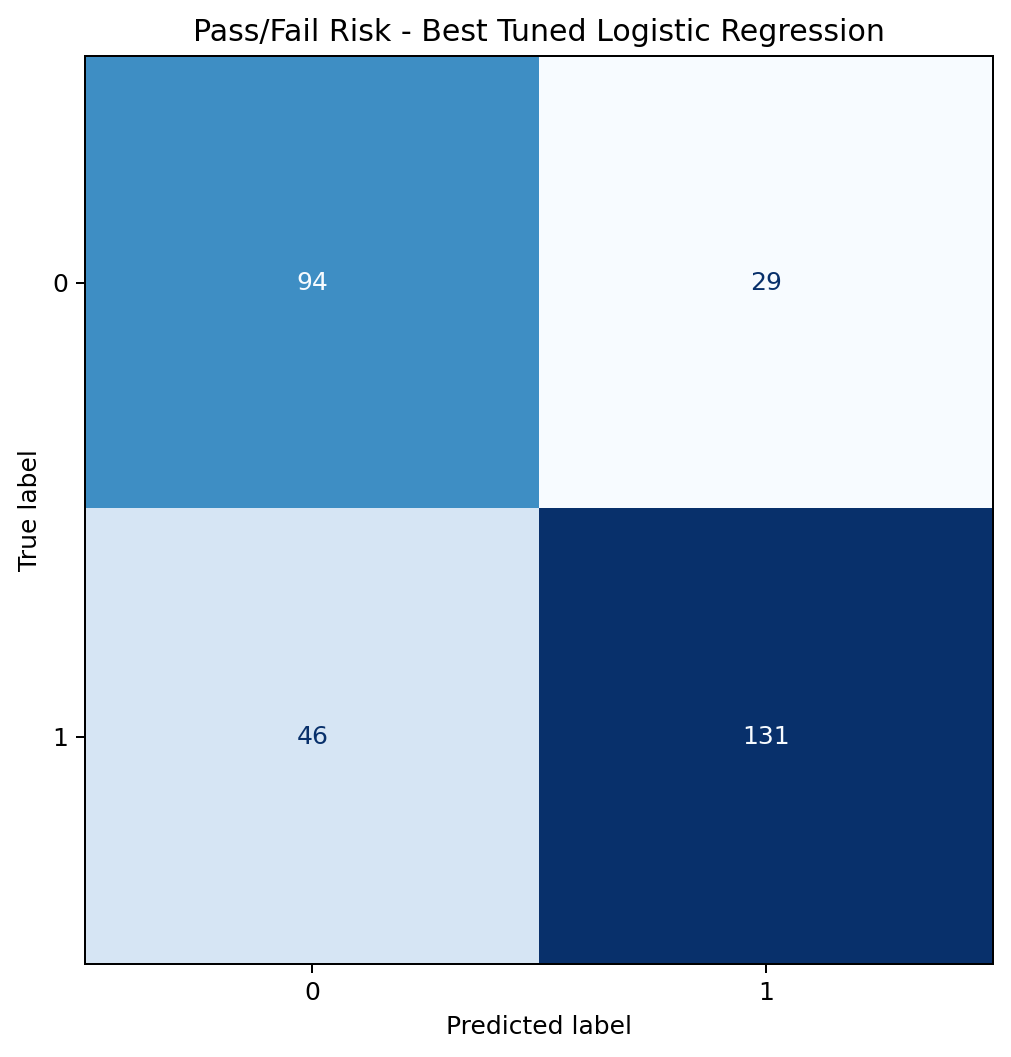

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/commerce_risk_best_tuned_confusion_matrix.png


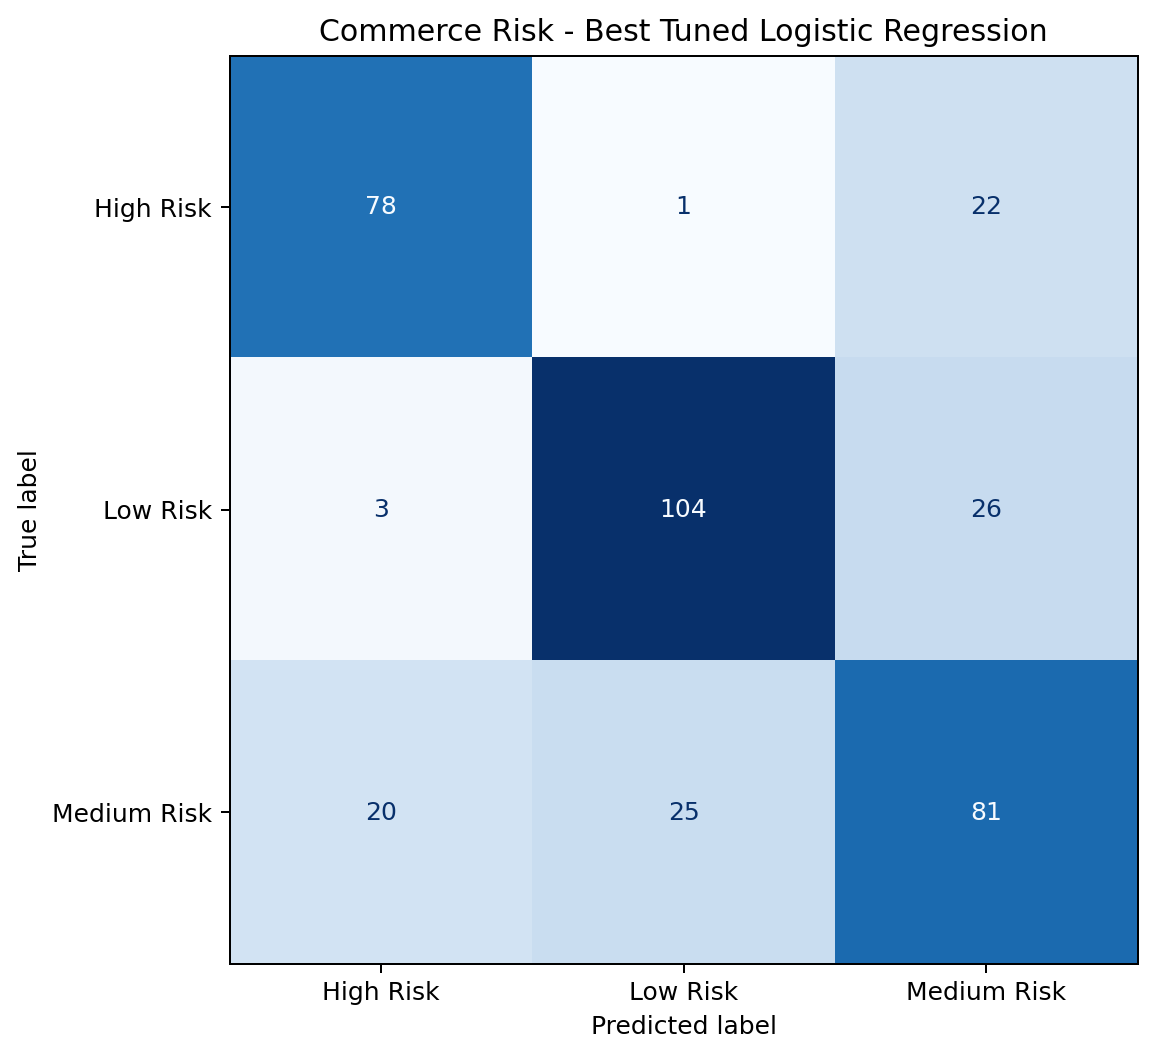

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/xapi_benchmark_best_tuned_confusion_matrix.png


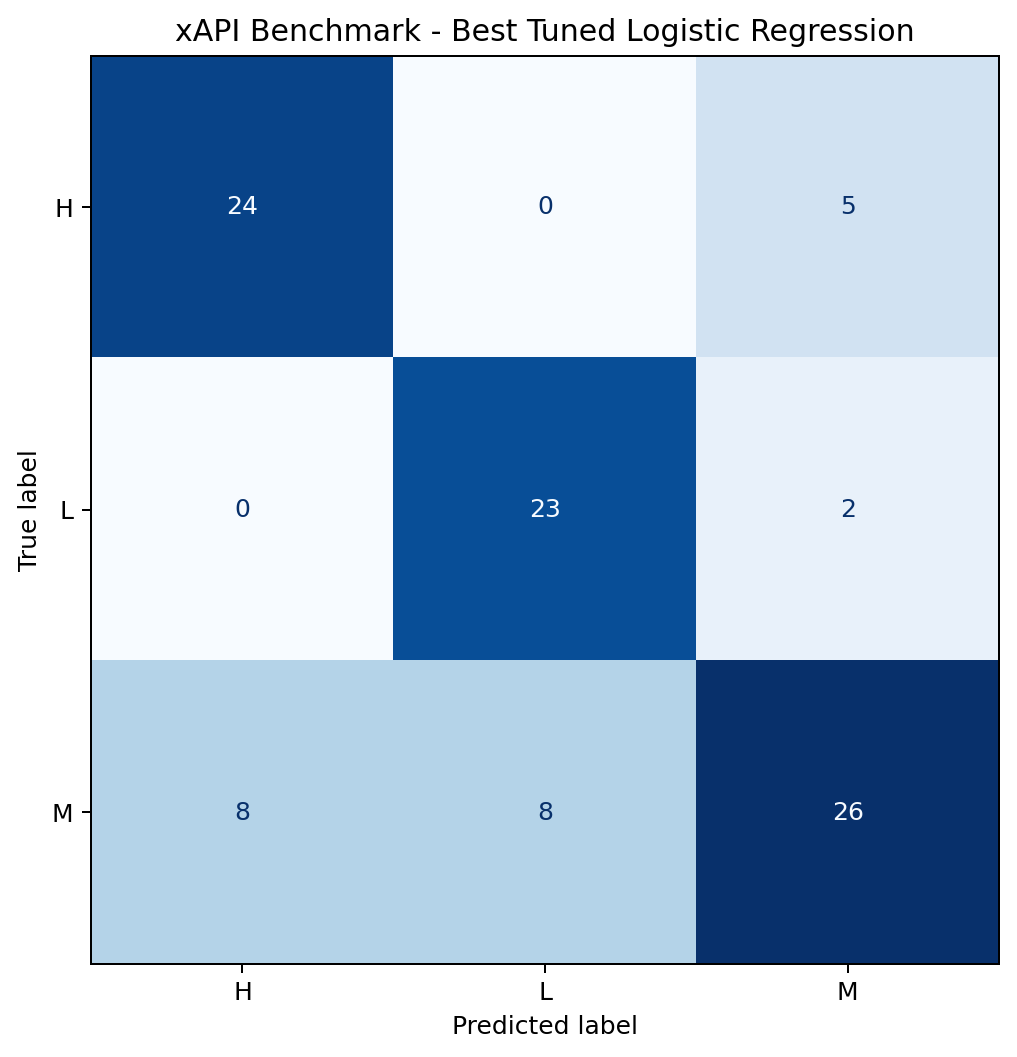

In [14]:
for task_name, task in task_definitions.items():
    _, X_test, _, y_test = split_data[task_name]
    y_pred = best_predictions[task_name]
    labels = task["labels"]
    best_model_name = best_tuned_models[task_name]["model_name"]

    output_path = FIGURES_DIR / f"{clean_task_name(task_name)}_best_tuned_confusion_matrix.png"
    save_confusion_matrix(
        y_test,
        y_pred,
        labels,
        f"{task_name} - Best Tuned {best_model_name}",
        output_path,
    )

## 16. Best Parameter Table

In [15]:
parameter_rows = []

for task_name, best_info in best_tuned_models.items():
    for parameter, value in best_info["best_params"].items():
        parameter_rows.append({
            "Task": task_name,
            "Best Tuned Model": best_info["model_name"],
            "Parameter": parameter,
            "Value": value,
        })

best_parameters_df = pd.DataFrame(parameter_rows)
display(best_parameters_df)

best_parameters_path = TUNING_DIR / "best_tuned_parameters.csv"
best_parameters_df.to_csv(best_parameters_path, index=False)
print("Saved:", best_parameters_path)

,Task,Best Tuned Model,Parameter,Value
0,Pass/Fail Risk,Logistic Regression,model__C,0.1
1,Pass/Fail Risk,Logistic Regression,model__solver,liblinear
2,Commerce Risk,Logistic Regression,model__C,0.1
3,Commerce Risk,Logistic Regression,model__solver,lbfgs
4,xAPI Benchmark,Logistic Regression,model__C,0.1
5,xAPI Benchmark,Logistic Regression,model__solver,lbfgs


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/best_tuned_parameters.csv


## 17. Tuning Decision Notes

The final notebook should use these tuning outputs to decide which model should be exported. A tuned model is not automatically better just because it has more parameters. The final choice should consider:

- test-set performance
- cross-validation performance
- model simplicity
- class-imbalance behaviour
- project relevance
- whether the dataset contains all required target classes

For the current Commerce Risk dataset, note that the available processed data may not contain all three expected risk classes. This should be mentioned in the final documentation if it remains true.

In [16]:
decision_notes = {
    "notebook": "04_Hyperparameter_Tuning.ipynb",
    "random_state": RANDOM_STATE,
    "selection_metric": "balanced_accuracy with Macro F1 as supporting evidence",
    "core_project_models": [
        "Pass/Fail Risk",
        "Commerce Risk",
    ],
    "optional_benchmark_model": "xAPI Benchmark",
    "data_leakage_prevention": [
        "Pipelines fit imputation and scaling inside training folds only.",
        "Commerce Subject_Average is excluded from feature matrix.",
        "xAPI Class_Encoded is excluded from feature matrix.",
    ],
    "outputs": {
        "tuning_results": str(tuning_results_path),
        "baseline_vs_tuned": str(comparison_path),
        "best_tuned_summary": str(best_summary_path),
        "best_parameters": str(best_parameters_path),
    },
}

notes_path = TUNING_DIR / "hyperparameter_tuning_decision_notes.json"
notes_path.write_text(json.dumps(decision_notes, indent=2))
print("Saved:", notes_path)

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/hyperparameter_tuning_decision_notes.json


## 19. Final Conclusion

This notebook performed hyperparameter tuning for the Smart Learning System ML models using leakage-safe scikit-learn pipelines and stratified cross-validation.

The Pass/Fail Risk and Commerce Risk models are the core project-aligned models. The xAPI model is tuned as an optional benchmark model for research/demo value. Baseline and tuned models were compared using accuracy, balanced accuracy, precision, recall, F1-score and cross-validation results.

The generated tuning outputs can now be used by `05_Final_Evaluation_Export.ipynb` to select and export the final production-ready models, feature-column files and documentation summaries.